# 2 — The ladder, the threshold, and what each is worth

Everything here reads the frozen artifacts. Model selection, hyperparameters
and thresholds were fixed on validation by `src/models/run_training.py`; the
test split was read once by `src/evaluation/run_eval.py`. Nothing in this
notebook tunes anything.

The argument, in order:

1. The models, ranked by AUC and then by money. The orders differ.
2. The threshold is a bigger decision than the model.
3. `class_weight="balanced"` changes nothing and appears to change everything.
4. Ranking by probability is the wrong way to spend review capacity.
5. Who pays for the errors, and what it costs to stop them paying.

In [1]:
import sys, json
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.evaluation import decision as dec

BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#dcdbd6"
plt.rcParams.update({
    "figure.dpi": 120, "font.size": 9, "axes.edgecolor": GRID,
    "axes.labelcolor": MUTED, "text.color": INK, "xtick.color": MUTED,
    "ytick.color": MUTED, "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.6, "axes.spines.top": False, "axes.spines.right": False,
})

R = "../output/reports/"
val = json.load(open(R + "validation.json"))
res = json.load(open(R + "test_results.json"))
fair = json.load(open(R + "fairness.json"))
scores = pd.read_csv(R + "test_scores.csv.gz")

y = scores["default"].to_numpy()
exposure = scores["exposure"].to_numpy()
ratio = res["cost_ratio"]
n_good = int((y == 0).sum())
print(f"test: {len(y):,} accounts, {int(y.sum()):,} defaults ({y.mean():.4f})")
print(f"cost ratio R = {ratio}, break-even threshold {dec.optimal_threshold(ratio):.4f}")
print(f"declining everyone costs {n_good:,}; approving everyone costs "
      f"{int(y.sum()) * ratio:,.0f}")

test: 7,500 accounts, 1,659 defaults (0.2212)
cost ratio R = 7.5, break-even threshold 0.1176
declining everyone costs 5,841; approving everyone costs 12,442


## 1. Two orderings

Each model at the threshold frozen on validation. `saved` is against the
better of the two policies that need no model at all.

In [2]:
LADDER = ["base_rate", "delinquency_rule", "logistic", "logistic_balanced",
          "random_forest", "hist_gbm", "hist_gbm_calibrated"]
rows = []
for k in LADDER:
    m = res["models"][k]
    rows.append({
        "model": k, "AUC": m["roc_auc"], "ECE": m["ece"],
        "threshold": m["threshold_from_validation"],
        "regret": m["regret"], "regret@0.5": m["regret_at_half"],
        "saved": m["value"]["saved_vs_best_naive"],
    })
table = pd.DataFrame(rows)
display(table.style.format({
    "AUC": "{:.4f}", "ECE": "{:.4f}", "threshold": "{:.3f}",
    "regret": "{:,.1f}", "regret@0.5": "{:,.1f}", "saved": "{:+,.1f}"}).hide(axis="index"))

model,AUC,ECE,threshold,regret,regret@0.5,saved
base_rate,0.5000,0.0000,0.001,"5,841.0","12,442.5",+0.0
delinquency_rule,0.7205,0.0119,0.001,"5,841.0","8,434.5",+0.0
logistic,0.7377,0.0535,0.063,"5,637.0","9,597.5",+204.0
logistic_balanced,0.7371,0.2379,0.218,"5,662.5","5,832.0",+178.5
random_forest,0.7926,0.0234,0.129,"4,695.0","8,061.0","+1,146.0"
hist_gbm,0.7881,0.0115,0.102,"4,712.5","7,933.0","+1,128.5"
hist_gbm_calibrated,0.7913,0.0126,0.114,"4,736.5","7,991.5","+1,104.5"


**The delinquency rule has an AUC of 0.72 and is worth nothing.** Its
cheapest policy at this cost ratio is to decline every applicant, which
needs no model. AUC 0.72 sounds like a working model; priced as a decision
it is indistinguishable from a constant.

And the jump from AUC 0.738 to 0.788 — five points — multiplies the money
saved by five and a half. Nothing about the AUC scale tells you that.

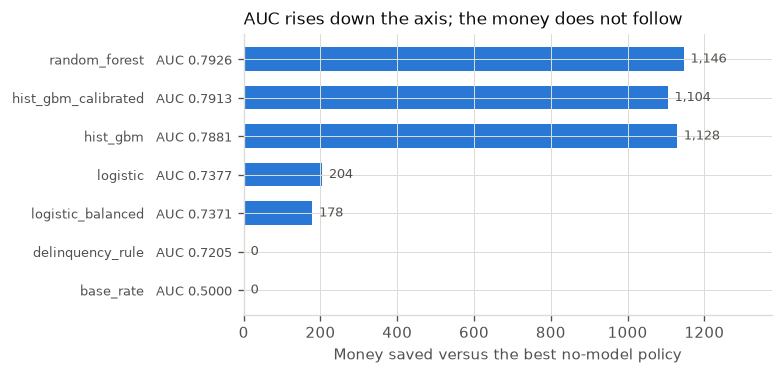

In [3]:
fig, ax = plt.subplots(figsize=(6.6, 3.2))
t = table.sort_values("AUC")
ax.barh(range(len(t)), t["saved"], color=BLUE, height=0.62)
ax.set_yticks(range(len(t)))
ax.set_yticklabels([f"{m}   AUC {a:.4f}" for m, a in zip(t["model"], t["AUC"])],
                   fontsize=8)
for i, v in enumerate(t["saved"]):
    ax.text(v + 18, i, f"{v:,.0f}", va="center", fontsize=8, color=MUTED)
ax.set_xlabel("Money saved versus the best no-model policy")
ax.set_xlim(0, t["saved"].max() * 1.2)
ax.set_title("AUC rises down the axis; the money does not follow",
             loc="left", color=INK, fontsize=10)
plt.tight_layout(); plt.show()

## 2. The threshold is the bigger decision

The same fitted model, priced across every threshold. The minimum sits near
0.10; the familiar 0.5 sits in a region where the model is **worse than
lending to nobody**.

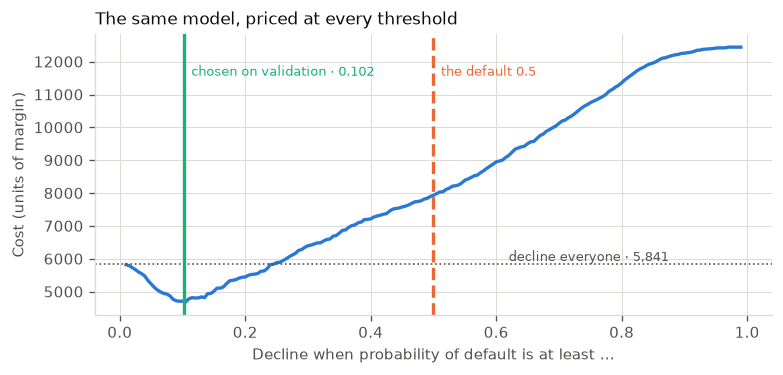

at the validation threshold : 4,712.5
at 0.5                      : 7,933.0  (+68.3%)
declining everyone          : 5,841.0


In [4]:
p = scores["p_hist_gbm"].to_numpy()
grid = np.linspace(0.01, 0.99, 197)
curve = [dec.regret(y, p, t, ratio) for t in grid]
t_sel = res["models"]["hist_gbm"]["threshold_from_validation"]

fig, ax = plt.subplots(figsize=(6.6, 3.2))
ax.plot(grid, curve, color=BLUE, lw=2)
ax.axhline(n_good, color=MUTED, lw=1, ls=":")
ax.text(0.62, n_good + 90, f"decline everyone · {n_good:,}", fontsize=8, color=MUTED)
ax.axvline(t_sel, color=AQUA, lw=2)
ax.text(t_sel + 0.012, max(curve) * 0.93, f"chosen on validation · {t_sel:.3f}",
        fontsize=8, color=AQUA)
ax.axvline(0.5, color=ORANGE, lw=2, ls="--")
ax.text(0.512, max(curve) * 0.93, "the default 0.5", fontsize=8, color=ORANGE)
ax.set_xlabel("Decline when probability of default is at least ...")
ax.set_ylabel("Cost (units of margin)")
ax.set_title("The same model, priced at every threshold", loc="left",
             color=INK, fontsize=10)
plt.tight_layout(); plt.show()

print(f"at the validation threshold : {dec.regret(y, p, t_sel, ratio):,.1f}")
print(f"at 0.5                      : {dec.regret(y, p, 0.5, ratio):,.1f}  "
      f"({dec.regret(y, p, 0.5, ratio) / dec.regret(y, p, t_sel, ratio) - 1:+.1%})")
print(f"declining everyone          : {n_good:,.1f}")

### And this does not depend on believing R = 7.5

The penalty for cutting at 0.5 as a function of the cost ratio. At R = 1 —
the assumption 0.5 actually encodes — there is no penalty, which is the
point. Every ratio a lender would recognise is far from there.

ratio,theoretical_threshold,empirical_threshold,regret_at_empirical,regret_at_half,penalty
1.0,0.5000,0.544,"1,323","1,329",+0.5%
2.0,0.3333,0.336,"2,235","2,345",+4.9%
3.0,0.2500,0.231,"2,965","3,361",+13.4%
5.0,0.1667,0.136,"4,036","5,393",+33.6%
7.5,0.1176,0.104,"4,686","7,933",+69.3%
10.0,0.0909,0.089,"5,041","10,473",+107.8%
15.0,0.0625,0.057,"5,484","15,553",+183.6%
20.0,0.0476,0.031,"5,711","20,633",+261.3%


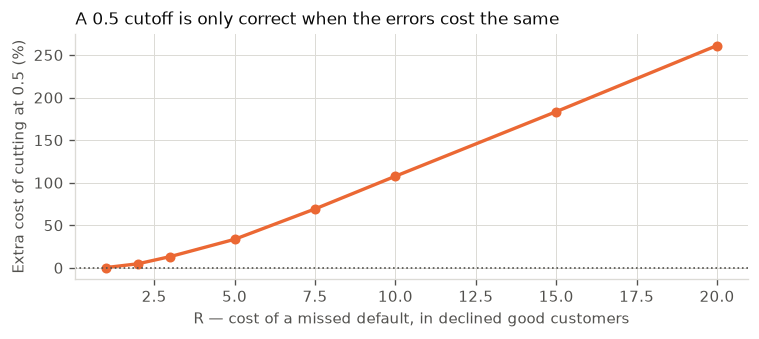

In [5]:
sens = pd.DataFrame(res["threshold_study"]["ratio_sensitivity"])
sens["penalty"] = sens["regret_at_half"] / sens["regret_at_empirical"] - 1
display(sens[["ratio", "theoretical_threshold", "empirical_threshold",
              "regret_at_empirical", "regret_at_half", "penalty"]].style.format({
    "ratio": "{:.1f}", "theoretical_threshold": "{:.4f}",
    "empirical_threshold": "{:.3f}", "regret_at_empirical": "{:,.0f}",
    "regret_at_half": "{:,.0f}", "penalty": "{:+.1%}"}).hide(axis="index"))

fig, ax = plt.subplots(figsize=(6.4, 2.9))
ax.plot(sens["ratio"], sens["penalty"] * 100, color=ORANGE, lw=2, marker="o", ms=5)
ax.axhline(0, color=MUTED, lw=1, ls=":")
ax.set_xlabel("R — cost of a missed default, in declined good customers")
ax.set_ylabel("Extra cost of cutting at 0.5 (%)")
ax.set_title("A 0.5 cutoff is only correct when the errors cost the same",
             loc="left", color=INK, fontsize=10)
plt.tight_layout(); plt.show()

## 3. The imbalance reflex

`class_weight="balanced"` is what people reach for when a dataset is 22%
positive. Against the plain logistic regression it is measurably nothing —
and at a 0.5 cutoff it looks like a large improvement.

In [6]:
s = res["significance"]["logistic_balanced_vs_logistic"]
print("balanced vs plain logistic, on the held-out split")
print(f"  AUC difference      {s['auc']['point_estimate']:+.4f} "
      f"[{s['auc']['ci_low']:+.4f}, {s['auc']['ci_high']:+.4f}]")
r = s["regret_per_account"]
print(f"  regret per account  {r['point_estimate']:+.4f} "
      f"[{r['ci_low']:+.4f}, {r['ci_high']:+.4f}]")
print(f"  McNemar on decisions p = {s['mcnemar_on_decisions']['p_value']:.3f}")
print()
a, b = res["models"]["logistic_balanced"], res["models"]["logistic"]
print(f"  ECE          balanced {a['ece']:.4f}   plain {b['ece']:.4f}")
print(f"  cost at 0.5  balanced {a['regret_at_half']:,.0f}   plain {b['regret_at_half']:,.0f}"
      f"   -> looks {1 - a['regret_at_half'] / b['regret_at_half']:.0%} better")
print(f"  cost at each model's own threshold: "
      f"balanced {a['regret']:,.0f}   plain {b['regret']:,.0f}")

balanced vs plain logistic, on the held-out split
  AUC difference      -0.0007 [-0.0015, +0.0002]
  regret per account  +0.0034 [-0.0009, +0.0083]
  McNemar on decisions p = 0.382

  ECE          balanced 0.2379   plain 0.0535
  cost at 0.5  balanced 5,832   plain 9,598   -> looks 39% better
  cost at each model's own threshold: balanced 5,662   plain 5,637


Every difference that matters is null. The 39% "improvement" at 0.5 is the
weighting having moved the probabilities to where 0.5 is a less absurd place
to cut — bought at the price of a calibration error four times larger. The
model did not get better; the arbitrary threshold got luckier.

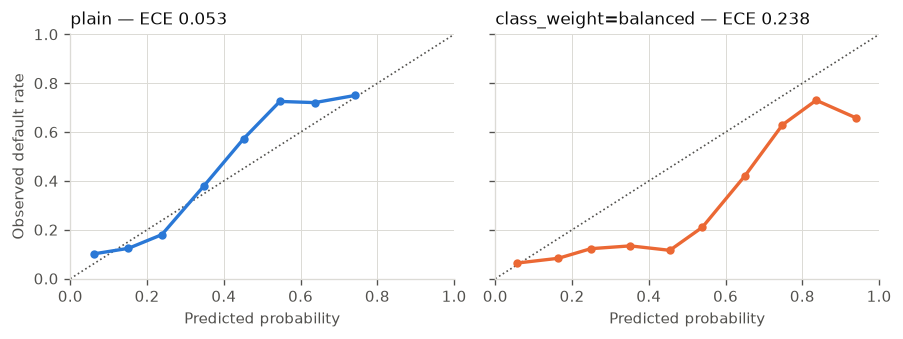

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(7.6, 2.9), sharey=True)
for ax, key, title in [(axes[0], "logistic", "plain"),
                       (axes[1], "logistic_balanced", "class_weight=balanced")]:
    bins = res["reliability"][key]
    xs = [b["mean_predicted"] for b in bins if b["n"] > 30]
    ys = [b["observed_rate"] for b in bins if b["n"] > 30]
    ax.plot([0, 1], [0, 1], color=MUTED, lw=1, ls=":")
    ax.plot(xs, ys, color=BLUE if key == "logistic" else ORANGE, lw=2, marker="o", ms=4)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel("Predicted probability")
    ax.set_title(f"{title} — ECE {res['models'][key]['ece']:.3f}",
                 loc="left", color=INK, fontsize=10)
axes[0].set_ylabel("Observed default rate")
plt.tight_layout(); plt.show()

## 4. Spending review capacity

A different decision: only K accounts can be reviewed. Rank by probability
of default, or by probability times the balance at risk?

K,K share,caught (by p),prevented (by p),caught (by p x exposure),prevented (by p x exposure),extra money
75,1%,63,"NT$3,834,701",48,"NT$12,806,554",+234.0%
375,5%,291,"NT$17,328,023",214,"NT$34,003,742",+96.2%
750,10%,536,"NT$32,811,019",372,"NT$47,072,555",+43.5%
1500,20%,860,"NT$44,543,729",618,"NT$61,092,839",+37.2%


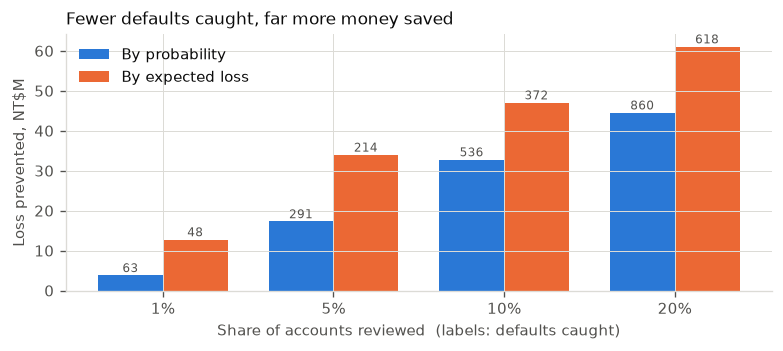

In [8]:
tk = pd.DataFrame([{
    "K": r["k"], "K share": r["k_fraction"],
    "caught (by p)": r["by_probability"]["defaults_caught"],
    "prevented (by p)": r["by_probability"]["loss_prevented"],
    "caught (by p x exposure)": r["by_expected_loss"]["defaults_caught"],
    "prevented (by p x exposure)": r["by_expected_loss"]["loss_prevented"],
} for r in res["topk_review"]])
tk["extra money"] = tk["prevented (by p x exposure)"] / tk["prevented (by p)"] - 1
display(tk.style.format({
    "K share": "{:.0%}", "prevented (by p)": "NT${:,.0f}",
    "prevented (by p x exposure)": "NT${:,.0f}",
    "extra money": "{:+.1%}"}).hide(axis="index"))

fig, ax = plt.subplots(figsize=(6.6, 3.0))
x = np.arange(len(tk)); w = 0.38
ax.bar(x - w/2, tk["prevented (by p)"] / 1e6, w, color=BLUE, label="By probability")
ax.bar(x + w/2, tk["prevented (by p x exposure)"] / 1e6, w, color=ORANGE,
       label="By expected loss")
for i in range(len(tk)):
    ax.text(x[i] - w/2, tk["prevented (by p)"][i] / 1e6 + 0.8,
            f"{tk['caught (by p)'][i]}", ha="center", fontsize=7, color=MUTED)
    ax.text(x[i] + w/2, tk["prevented (by p x exposure)"][i] / 1e6 + 0.8,
            f"{tk['caught (by p x exposure)'][i]}", ha="center", fontsize=7, color=MUTED)
ax.set_xticks(x); ax.set_xticklabels([f"{v:.0%}" for v in tk["K share"]])
ax.set_xlabel("Share of accounts reviewed  (labels: defaults caught)")
ax.set_ylabel("Loss prevented, NT$M")
ax.legend(frameon=False, loc="upper left")
ax.set_title("Fewer defaults caught, far more money saved", loc="left",
             color=INK, fontsize=10)
plt.tight_layout(); plt.show()

At 1% capacity, ranking by expected loss catches **48 defaults instead of
63** and prevents **3.3x the money**. Recall prefers the first ordering.
Precision prefers the first ordering. AUC prefers the first ordering. All
three are indifferent to the fact that one balance can be a hundred times
another, and the decision is not.

## 5. Who pays

One global threshold on a model that ranks about equally well in every
group. The AUC gaps are small; the error-rate gaps are not, because the
groups default at different rates.

In [9]:
for attr in ("SEX", "AGE_BAND", "EDUCATION"):
    a = fair["audit"][attr]
    rows = [{"group": g["label"], "n": g["n"], "base rate": g["base_rate"],
             "declined": g["flag_rate"], "recall": g["recall"], "FPR": g["fpr"],
             "AUC": g["roc_auc"], "reportable": "yes" if g["reliable"] else "no"}
            for g in a["groups"]]
    print(f"=== {attr} — one threshold at {a['threshold']:.3f} ===")
    display(pd.DataFrame(rows).style.format({
        "base rate": "{:.4f}", "declined": "{:.4f}", "recall": "{:.4f}",
        "FPR": "{:.4f}", "AUC": "{:.4f}"}).hide(axis="index"))
    g = a["gaps"]
    print(f"gaps — declined {g['demographic_parity_gap']:.4f}  "
          f"recall {g['equal_opportunity_gap']:.4f}  "
          f"FPR {g['false_positive_rate_gap']:.4f}  AUC {g['auc_gap']:.4f}\n")

=== SEX — one threshold at 0.102 ===


group,n,base rate,declined,recall,FPR,AUC,reportable
Male,3017,0.2463,0.6815,0.9031,0.6091,0.7841,yes
Female,4483,0.2043,0.6081,0.8745,0.5397,0.7888,yes


gaps — declined 0.0734  recall 0.0286  FPR 0.0694  AUC 0.0047

=== AGE_BAND — one threshold at 0.102 ===


group,n,base rate,declined,recall,FPR,AUC,reportable
21-29,2420,0.2202,0.6645,0.9006,0.5978,0.7881,yes
30-39,2791,0.2082,0.5926,0.8640,0.5213,0.7885,yes
40-49,1626,0.2312,0.6371,0.8803,0.5640,0.7829,yes
50+,663,0.2549,0.7300,0.9408,0.6579,0.7935,yes


gaps — declined 0.1374  recall 0.0768  FPR 0.1366  AUC 0.0106

=== EDUCATION — one threshold at 0.102 ===


group,n,base rate,declined,recall,FPR,AUC,reportable
Graduate school,2661,0.1905,0.5415,0.8245,0.4749,0.7838,yes
University,3474,0.2375,0.6983,0.9200,0.6293,0.7875,yes
High school,1246,0.2592,0.7079,0.9009,0.6403,0.7698,yes
Other/unknown,119,0.0336,0.2773,1.0000,0.2522,0.9587,no


gaps — declined 0.1663  recall 0.0955  FPR 0.1654  AUC 0.0177



### The two fixes, priced

The reflex fix is to delete the protected attributes. The unfashionable fix
is to keep them and set a threshold per group. They do not cost the same and
they do not work equally well.

In [10]:
rows = []
for attr in ("SEX", "AGE_BAND", "EDUCATION"):
    a = fair["audit"][attr]
    for key, label in [("cost_of_equal_opportunity", "equal recall"),
                       ("cost_of_demographic_parity", "equal decline rate")]:
        c = a[key]
        rows.append({
            "attribute": attr, "intervention": f"per-group threshold, {label}",
            "cost": c["extra_regret_pct"] / 100,
            "decline gap before": c["gaps_before"]["demographic_parity_gap"],
            "decline gap after": c["gaps_after"]["demographic_parity_gap"],
        })
b = fair["blinded"]
base_regret = res["models"]["hist_gbm"]["regret"]
for attr in ("SEX", "AGE_BAND", "EDUCATION"):
    rows.append({
        "attribute": attr, "intervention": "drop sex, age, education, marriage",
        "cost": b["regret"] / base_regret - 1,
        "decline gap before": fair["audit"][attr]["gaps"]["demographic_parity_gap"],
        "decline gap after": b["gaps"][attr]["demographic_parity_gap"],
    })
out = pd.DataFrame(rows)
out["gap closed"] = 1 - out["decline gap after"] / out["decline gap before"]
display(out.style.format({
    "cost": "{:+.2%}", "decline gap before": "{:.4f}",
    "decline gap after": "{:.4f}", "gap closed": "{:.0%}"}).hide(axis="index"))

print(f"blinded model: AUC {b['roc_auc']:.4f} against the full model's "
      f"{res['models']['hist_gbm']['roc_auc']:.4f}")
print(f"  AUC difference    {b['vs_full_auc']['point_estimate']:+.4f} "
      f"[{b['vs_full_auc']['ci_low']:+.4f}, {b['vs_full_auc']['ci_high']:+.4f}]")
r = b["vs_full_regret"]
print(f"  regret/account    {r['point_estimate']:+.4f} "
      f"[{r['ci_low']:+.4f}, {r['ci_high']:+.4f}]  (positive = worse)")

attribute,intervention,cost,decline gap before,decline gap after,gap closed
SEX,"per-group threshold, equal recall",+0.74%,0.0734,0.0290,61%
SEX,"per-group threshold, equal decline rate",+1.11%,0.0734,0.0040,95%
AGE_BAND,"per-group threshold, equal recall",+0.14%,0.1374,0.0129,91%
AGE_BAND,"per-group threshold, equal decline rate",+0.58%,0.1374,0.0013,99%
EDUCATION,"per-group threshold, equal recall",+3.05%,0.1663,0.0571,66%
EDUCATION,"per-group threshold, equal decline rate",+1.73%,0.1663,0.0041,98%
SEX,"drop sex, age, education, marriage",+5.25%,0.0734,0.0163,78%
AGE_BAND,"drop sex, age, education, marriage",+5.25%,0.1374,0.0772,44%
EDUCATION,"drop sex, age, education, marriage",+5.25%,0.1663,0.1345,19%


blinded model: AUC 0.7832 against the full model's 0.7881
  AUC difference    -0.0049 [-0.0095, -0.0008]
  regret/account    +0.0330 [+0.0139, +0.0517]  (positive = worse)


**Deleting the attributes is the more expensive intervention and the less
effective one.** It costs about 5% of the model's value — significantly, the
interval excludes zero — and closes 78% of the decline-rate gap on sex but
only 19% of it on education, because six months of payment history proxies
for both. Setting a threshold per group costs between 0.1% and 3% and closes
almost all of the gap it targets.

That ordering is the opposite of the intuition, and it is the reason to
measure the intervention rather than assume it.

Two things this does not settle. Per-group thresholds mean explicitly using
a protected attribute in a lending decision, which in most jurisdictions is
illegal regardless of what it costs — the number here is what the law is
buying, not an argument against the law. And the definitions still disagree:
equalising recall leaves a decline-rate gap of 0.057 on education, and
equalising decline rates leaves a recall gap of 0.020. That disagreement is
a theorem, not a modelling failure.

## What the test split settled

| Claim | Evidence |
|---|---|
| AUC does not order models by value | Delinquency rule, AUC 0.7205, saves 0 |
| The threshold matters more than the model | 0.5 costs +68%, and loses to declining everyone |
| That is not an artifact of one cost ratio | Penalty is +34% at R=5, +262% at R=20 |
| `class_weight="balanced"` does nothing | AUC, regret and McNemar all null; ECE 4x worse |
| Ranking by probability misspends capacity | +234% money at K=1%, catching fewer defaults |
| Blinding is the costly, weak fix | +5% cost, closes 19% of the education gap |

The gradient boosting model and the random forest are statistically
indistinguishable on this split (AUC difference −0.0044, CI crossing zero) —
validation picked between two equivalent models, and saying so is more
useful than presenting the winner as a finding.